# Solve 1D Wave equation: 
\begin{equation}
\begin{cases} 
    u_{tt}(x,t) - 4u_{xx}(x,t) = 0 \quad x \in [0, 1], \ t \in [0, 1] \\ 
    u(0,t) = u(1,t) = 0 \\ 
    u_{t}(x,0) = 0 \\ 
    u(x,0) = \sin(\pi x) + \frac{1}{2} \sin(4\pi x) 
\end{cases}
\end{equation} 
$$
u(x,t) = \sin(\pi x) \cos(2\pi t) + \frac{1}{2} \sin(4\pi x) \cos(8\pi t)  
$$

In [8]:
import torch 
from torch import nn
import math 
import numpy as np 
import matplotlib.pyplot as plt 
from mpl_toolkits.axes_grid1 import make_axes_locatable # allows you to easily add new axes next to an existing plot 
from utils.RFN_structure import * 
from utils.data import *

import Wave_utils
import importlib
importlib.reload(Wave_utils)
from Wave_utils import * 

import warnings

# warnings.filterwarnings('ignore') 
import time 

In [2]:
# MPS or CUDA or CPU 
if torch.backends.mps.is_available(): 
    device = torch.device('mps') 
elif torch.cuda.is_available(): 
    device = torch.device('cuda') 
else: 
    devcie = torch.device('cpu') 

print(f"Wroking on {device}") 

Wroking on mps


# Using Product Random Feature Model: 
\begin{equation}
u(x) = \sum_{i=1}^{N_{t}} \sum_{k=1}^{N_{x}}  c_{i,k} \cos(<\omega_{k}^{x}, x> + b_{k}) \cos(<\omega_{i}^{t}, t> + d_{i})  
\end{equation} 

Only train the coefficients $c_{i,k}$

In [3]:
class RFN_Wave(nn.Module): 
    def __init__(self, X_train, X_init, u_init, T_bc, lb, ub, Dx, Dt, scale_x = 1.0, 
                 scale_t = 1.0, out_dim = 1):
        super().__init__() 
        # set up parameters for random features 
        self.Dx = Dx 
        # self.scale_x = scale_x 
        self.Dt = Dt 
        # self.scale_t = scale_t 
        
        # Model setting 
        self.rfn = Random_Feature_model(Dx, Dt, scale_x, scale_t).to(device) 
        self.Lambda = nn.Parameter(torch.zeros(1, device = device)) 
        
        # Domain bounds 
        self.lb = torch.as_tensor(lb, dtype = torch.float32, device = device)
        self.ub = torch.as_tensor(ub, dtype = torch.float32, device = device)

        # Collocation data points 
        self.x = torch.tensor(X_train[:, 0:1], requires_grad = True).float().to(device) 
        self.t = torch.tensor(X_train[:, 1:2], requires_grad = True).float().to(device) 
        self.X_train = torch.tensor(X_train, requires_grad = False).float().to(device) 
        self.N_int = self.x.shape[0]
        
        # Initial data 
        self.x_init = torch.tensor(X_init[:]).float().to(device) # (N_init, 1) 
        self.x_init.requires_grad_(True) 
        self.t_init = torch.zeros_like(self.x_init).float().to(device) # (N_init, 1)
        self.t_init.requires_grad_(True) 
        self.X_init = torch.cat([self.x_init, self.t_init], dim = 1) 
        self.u_init = torch.tensor(u_init).float().to(device) 
        self.N_init = self.x_init.shape[0]
        
        # Boundary data 
        self.t_bc = torch.tensor(T_bc).float().to(device) 
        self.x_left = self.lb[0] * torch.ones_like(self.t_bc).float().to(device)
        self.x_right = self.ub[0] * torch.ones_like(self.t_bc).float().to(device)

        self.X_left = torch.cat([self.x_left, self.t_bc], dim = 1) 
        self.X_right = torch.cat([self.x_right, self.t_bc], dim = 1) 
        self.N_bc = self.t_bc.shape[0]

        # Regularization parameters 
        self.lambda1 = 1.0        
        self.lambda2 = 1.0 
        self.lambda3 = 1.0
        
        # Iteration parameter 
        self.iter = 0 
        
        # Adam Optimizer 
        self.optimizer_Adam = torch.optim.Adam(self.rfn.parameters(), lr = 1e-4, betas = (0.9, 0.999), weight_decay = 0.0) 
        """ 
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer_Adam,
            factor = 0.5,
            patience = 50
        )
        """ 
        # Optimizers 2nd order optimizer 
        self.optimizer = torch.optim.LBFGS(
            self.rfn.parameters(), # target to be optimized; parameters must be in a list
            lr = 1.0, # learning rate: step length 
            max_iter = 1, # maximum number of iterations 
            max_eval = 50000, # total number of times the closure (loss + backward pass) can be called 
            history_size = 50, 
            tolerance_grad = 1e-7, 
            tolerance_change = 1e-9, 
            line_search_fn = "strong_wolfe"
        ) 

    
    def net_u(self, x, t): # predicted value 
        u = self.rfn(x, t) 
        return u 

    def PDE_residual(self, x, t): 
        u = self.net_u(x, t) 

        u_x = torch.autograd.grad(
            u, x, 
            grad_outputs = torch.ones_like(u), 
            create_graph = True
        )[0]

        u_xx = torch.autograd.grad(
            u_x, x, 
            grad_outputs = torch.ones_like(u_x), 
            create_graph = True
        )[0] 

        u_t = torch.autograd.grad( 
            u, t, 
            grad_outputs = torch.ones_like(u), 
            create_graph = True 
        )[0] 

        u_tt = torch.autograd.grad(
            u_t, t, 
            grad_outputs = torch.ones_like(u_t), 
            create_graph = True
        )[0] 

        # PDE residual loss 
        f = u_tt - 4 * u_xx 
        return f 
        
    def Init_loss_func(self): 
        u0 = self.net_u(self.x_init, self.t_init) 
        u0_t = torch.autograd.grad( 
            u0, self.t_init, 
            grad_outputs = torch.ones_like(u0), 
            create_graph = True 
        )[0] 
        Init_loss = torch.mean(torch.pow(self.u_init - u0, 2)) * self.lambda1 + torch.mean(torch.pow(u0_t, 2))  
        return Init_loss 
    
    def Bc_loss_func(self):
        u_left = self.net_u(self.x_left, self.t_bc) 
        u_right = self.net_u(self.x_right, self.t_bc) 
        bc_loss = (torch.mean(torch.pow(u_left, 2)) + torch.mean(torch.pow(u_right, 2))) * self.lambda2 
        return bc_loss 
        
    # Optimization step
    def loss_func(self): 
        f_pred = self.PDE_residual(self.x, self.t)         
        loss = torch.mean(torch.pow(f_pred, 2)) * self.lambda1 + self.Bc_loss_func() + self.Init_loss_func()  
        return loss 
    
    def closure(self): 
        loss_value = self.loss_func() 
        self.optimizer.zero_grad()                             # reset gradients
        loss_value.backward()                                  # compute gradients but only the network weights will be updated 
        return loss_value  
        
    def Optimize(self, nIter_1, nIter_2 = 2000): 
        # self.rfn.train() 
        # Two Phase Optimization
        # Step 1: Adam: gradient descent method 
        for epoch in range(nIter_1):
            # total loss 
            loss = self.loss_func() 
            
            # Backward and optimize 
            # Network parameter update 
            self.optimizer_Adam.zero_grad()            
            loss.backward()
            self.optimizer_Adam.step() # only sees the gradient of the network weights 

            if epoch % 100 == 0: 
                print(
                    'It: %d, Loss: %.3e' % 
                    ( 
                        epoch, 
                        loss.item()  
                    )
                )
        # Second Phase Optimization         
        for i in range(nIter_2):
            loss_value = self.optimizer.step(self.closure) # Never pass tensors into optimizer.step()
            self.iter += 1
            if self.iter % 100 == 0:
                print('It: %d, Loss: %e' % (self.iter, loss_value.item()))
                
    def predict(self, X, X_bc = None, T_bc = None): 
        x = torch.tensor(X[:, 0:1], requires_grad = True).float().to(device) 
        t = torch.tensor(X[:, 1:2], requires_grad = True).float().to(device) 
        # self.rfn.eval() 
        with torch.no_grad():
            u = self.net_u(x, t)
        f = self.PDE_residual(x, t) 

        u = u.detach().cpu().numpy()
        f = f.detach().cpu().numpy() 
        return u, f         

# Configurations 

In [4]:
# Domain bounds 
lb = np.array([0.0, 0.0]) # second element for time 
ub = np.array([1.0, 1.0]) # second element for time                                                

# Grid point setup 
N_bc = 100
Nx_int = 50
Nt_int = 100 
N_init = 100  

# Training points
X_train_int = interior_points(Nx_int, Nt_int, lb[0], ub[0], lb[1], ub[1]) 
print(f"X_train_int shape: {np.shape(X_train_int)}")

X_train_init = init_points(N_init, lb[0], ub[0]) 
U_train_init = u_0(X_train_init)
print('X_train_init shape: ', np.shape(X_train_init)) 
print('U_train_init shape: ', np.shape(U_train_init)) 

T_bc = bc_points(N_bc, lb[1], ub[1])
print('T_bc shape: ', np.shape(T_bc)) 

X_train_int shape: (5000, 2)
X_train_init shape:  (100, 1)
U_train_init shape:  (100, 1)
T_bc shape:  (100, 1)


# Generate Test data and solution  

In [9]:
Nx = 200; Nt = 50 
X_test, u_test = test_data(Nx, Nt, lb[0], ub[0], lb[1], ub[1])

print(f"X_test shape: {X_test.shape}") 
print(f"u_test shape: {u_test.shape}") 

X_test shape: (10000, 2)
u_test shape: (10000, 1)


# Training on Non-noisy Data 

In [10]:
noise = 0.0 
# training 
scale_x = 8.0 # 10.0 
scale_t = 16.0 # 20.0 
Dx = 70    # 60
Dt = 140 # 180
model = RFN_Wave(X_train_int, X_train_init, U_train_init, T_bc, lb, ub, Dx, Dt, scale_x, scale_t) 
start = time.time() 
model.Optimize(2500, 7000) 
end = time.time() 

It: 0, Loss: 2.356e+04
It: 100, Loss: 2.321e+01
It: 200, Loss: 5.553e+00
It: 300, Loss: 3.481e+00
It: 400, Loss: 2.508e+00
It: 500, Loss: 1.865e+00
It: 600, Loss: 1.424e+00
It: 700, Loss: 1.122e+00
It: 800, Loss: 9.113e-01
It: 900, Loss: 7.597e-01
It: 1000, Loss: 6.457e-01
It: 1100, Loss: 5.562e-01
It: 1200, Loss: 4.834e-01
It: 1300, Loss: 4.227e-01
It: 1400, Loss: 3.714e-01
It: 1500, Loss: 3.276e-01
It: 1600, Loss: 2.901e-01
It: 1700, Loss: 2.579e-01
It: 1800, Loss: 2.303e-01
It: 1900, Loss: 2.065e-01
It: 2000, Loss: 1.860e-01
It: 2100, Loss: 1.685e-01
It: 2200, Loss: 1.534e-01
It: 2300, Loss: 1.404e-01
It: 2400, Loss: 1.292e-01
It: 100, Loss: 7.906520e-02
It: 200, Loss: 6.882504e-02
It: 300, Loss: 6.354178e-02
It: 400, Loss: 5.859113e-02
It: 500, Loss: 5.518264e-02
It: 600, Loss: 5.163929e-02
It: 700, Loss: 4.923538e-02
It: 800, Loss: 4.735426e-02
It: 900, Loss: 4.574765e-02
It: 1000, Loss: 4.447817e-02
It: 1100, Loss: 4.276168e-02
It: 1200, Loss: 4.087375e-02
It: 1300, Loss: 3.89732

# Test the accuracy of the learned solution 

In [11]:
# evaluations 
u_pred, f_pred  = model.predict(X_test)  

print(f"u_pred shape: {np.shape(u_pred)}") 
# print(f"f_pred shape: {np.shape(f_pred)}")  
print(f"u_test shape: {np.shape(u_test)}") 

error_u = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2) # relative L^{2} square norm 
# error_f = np.linalg.norm(abs(f_pred), ord = np.inf) 

print('Error u: %e' % (error_u)) 
# print('PDE loss: %e' % (error_f)) 
print(f'Training time is {end - start:.2f} seconds')



u_pred shape: (10000, 1)
u_test shape: (10000, 1)
Error u: 7.306547e-02
Training time is 1348.65 seconds


# Collecting Error Data 

In [81]:
noise = 0.0 
err_l2 = np.zeros([10]) 
err_linf = np.zeros([10]) 
Training_time = np.zeros([10]) 
scale_x = 8.0 
scale_t = 16.0
Dx = 70
Dt = 140

training_sets = np.load(
    "Wave_Equation_training_points_sets.npy",
    allow_pickle=True
)
    
for k in range(10): 
    data = training_sets[k] 
    X_train_int = data["X_train_int"] 
    X_train_init = data["X_train_init"] 
    U_train_init = u_0(X_train_init)
    T_bc = data["T_bc"]
    model = RFN_Wave(X_train_int, X_train_init, U_train_init, T_bc, lb, ub, Dx, Dt, scale_x, scale_t) 
    start = time.time() 
    model.Optimize(2500, 8000) 
    end = time.time() 
    u_pred, f_pred = model.predict(X_test) 
    err_l2[k] = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2)
    err_linf[k] = np.max(np.abs(u_test - u_pred))
    Training_time[k] = (end - start) 

It: 0, Loss: 2.228e+04
It: 100, Loss: 2.625e+01
It: 200, Loss: 8.337e+00
It: 300, Loss: 3.819e+00
It: 400, Loss: 2.257e+00
It: 500, Loss: 1.452e+00
It: 600, Loss: 9.737e-01
It: 700, Loss: 6.876e-01
It: 800, Loss: 5.179e-01
It: 900, Loss: 4.161e-01
It: 1000, Loss: 3.530e-01
It: 1100, Loss: 3.115e-01
It: 1200, Loss: 2.823e-01
It: 1300, Loss: 2.603e-01
It: 1400, Loss: 2.426e-01
It: 1500, Loss: 2.277e-01
It: 1600, Loss: 2.145e-01
It: 1700, Loss: 2.110e-01
It: 1800, Loss: 1.917e-01
It: 1900, Loss: 1.814e-01
It: 2000, Loss: 1.719e-01
It: 2100, Loss: 1.628e-01
It: 2200, Loss: 1.741e-01
It: 2300, Loss: 1.463e-01
It: 2400, Loss: 1.388e-01
It: 100, Loss: 9.940886e-02
It: 200, Loss: 7.886731e-02
It: 300, Loss: 6.894302e-02
It: 400, Loss: 6.420760e-02
It: 500, Loss: 5.885230e-02
It: 600, Loss: 5.480664e-02
It: 700, Loss: 5.083629e-02
It: 800, Loss: 4.548911e-02
It: 900, Loss: 4.087051e-02
It: 1000, Loss: 3.707961e-02
It: 1100, Loss: 3.289668e-02
It: 1200, Loss: 3.051846e-02
It: 1300, Loss: 2.86926

In [82]:
print("Average RMSE: ", np.mean(err_l2))
print("Std of RMSE: ",  np.std(err_l2))
print("Average L_inf error: ", np.mean(err_linf))
print("Std of L_inf error: ", np.std(err_linf))

err_l2 mean:  0.04292621196617863
[0.05082814 0.02399886 0.03016017 0.02184988 0.16678913 0.02594421
 0.01142972 0.02079701 0.05343053 0.02403446]
0.04313612039155467
err_linf mean:  0.103891443136553
0.0890544183164619
Training_time mean:  1090.9384860992432
38.4108500116703


In [83]:
# Save the results 
results = {
    "Model": "RFN_Product",
    "num_features": [Dx, Dt] , 
    "Training_points_int_bc": [Nx_int, Nt_int, N_init, N_bc], 
    "Gaussian_scale": [scale_x, scale_t],
    "L2_error": err_l2,
    "Linf_error": err_linf,  
    "Training_time": Training_time,
}

# torch.save(results, "Wave_RFN_Product_Dx_70_Dt_140_data.pt")

# Visualization 

' \nfig.subplots_adjust(\n    wspace=0.08,\n    bottom=0.25\n)\n'

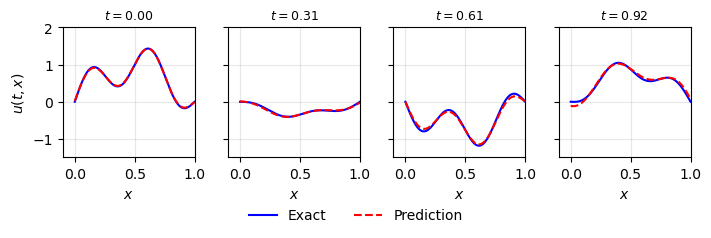

In [14]:
import matplotlib.gridspec as gridspec 

fig, axes = plt.subplots(
    1, 4,
    figsize=(7, 2),
    sharey=True,
    constrained_layout=True,
    gridspec_kw={'wspace': 0.1}
)
# fig.subplots_adjust(wspace=0.1)

times = [0, 15, 30, 45]

for ax, idx in zip(axes, times):
    ax.plot(
        X_test[idx*Nx:(idx+1)*Nx, 0:1],
        u_test[idx*Nx:(idx+1)*Nx],
        'b-',
        linewidth=1.5,
        label='Exact'
    )
    ax.plot(
        X_test[idx*Nx:(idx+1)*Nx, 0:1],
        u_pred[idx*Nx:(idx+1)*Nx,0],
        'r--',
        linewidth=1.5,
        label='Prediction'
    )

    ax.set_title(
        rf'$t={X_test[idx * Nx, 1]:.2f}$',
        fontsize=9
    )

    ax.set_xlim([-0.1,1.0])
    ax.set_ylim([-1.5,2.0])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r'$u(t,x)$')
for ax in axes:
    ax.set_xlabel(r'$x$')
""" 
axes[1].legend(
    loc='lower center',
    bbox_to_anchor=(0.5,-0.75),
    ncol=2,
    frameon=False
)
"""
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15)
)
""" 
fig.subplots_adjust(
    wspace=0.08,
    bottom=0.25
)
""" 
# fig.savefig("Wave_RFN.png", dpi=300, bbox_inches='tight')
